# **1. Projekt - Osnove podatkovne znanosti**

Odabrani podatkovni skup je generiran uz pomoć umjetne inteligencije i nema pripadajući link. Prikazuje podatke o bossevima u popularnoj igri Elden Ring. Sastoji se od 120 redaka i 10 stupaca.


# Rad sa bibliotekama

Uvoz potrebnih biblioteka:
1. pandas - biblioteka koju koristim za rad s tabličnim podacima; omogućava mi jednostavnu manipulaciju podacima iz mog data seta
2. matplotlib - biblioteka koja mi omogućava vizualizaciju podataka
3. seaborn - biblioteka koja mi također omogućava vizualizaciju podataka, temelji se na matplotlib-u
4. numpy - biblioteka koja mi olakšava rad sa nizevima brojeva i matricama; brze matematičke operacije


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Uvoz podataka

Uvoz csv filea u Google Colab te uvoz lokalno pohranjenih podataka:

In [3]:
from google.colab import files
fileovi = files.upload()

Saving elden_ring_data.csv to elden_ring_data.csv


In [8]:
df = pd.read_csv("elden_ring_data.csv")

# Pregled podataka

***.shape*** nam vraca dimenziju podatkovnog skupa (data framea) u formatu (broj redaka, broj stupaca)

In [28]:
df.shape

(120, 10)

***.info*** nam daje *vizualni prikaz tablice* te sažetak cijelog podatkovnog skupa:
1. RangeIndex (entries) govori koliko vrijednosti imamo u podatkovnom skupu
2. Data columns govori koliko je stupaca u skupu
3. Non-null count pokazuje ima li vrijednosti koje su "null", "0"...
4. dtypes govori i broji koje tipove podataka imamo u podatkovnom skupu

In [29]:
print("Informacije o podatkovnom skupu:\n")
df.info()

Informacije o podatkovnom skupu:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      120 non-null    int64 
 1   type                    120 non-null    object
 2   full_name               120 non-null    object
 3   region                  120 non-null    object
 4   progression_stage       120 non-null    object
 5   lore_difficulty_rating  120 non-null    int64 
 6   phase_count             120 non-null    int64 
 7   mandatory_fight         120 non-null    bool  
 8   arena_openness          120 non-null    object
 9   story_importance        120 non-null    int64 
dtypes: bool(1), int64(4), object(5)
memory usage: 8.7+ KB


***.head*** nam prikazuje prvih n redaka tablice
<br>Defaultni prikaz je prvih pet redaka, ali vrijednosti mogu biti bilo koje (npr. df.head(10), df.head(20)...)

In [75]:
print("Pregled podataka kojima raspolazemo:\n")
print(df.head(10))

Pregled podataka kojima raspolazemo:

   id  type                        full_name                      region  \
0   1  Boss            Margit, the Fell Omen                    Limgrave   
1   2  Boss              Godrick the Grafted                    Limgrave   
2   3  Boss  Rennala, Queen of the Full Moon        Liurnia of the Lakes   
3   4  Boss               Starscourge Radahn                      Caelid   
4   5  Boss        Rykard, Lord of Blasphemy                  Mt. Gelmir   
5   6  Boss           Morgott, the Omen King     Leyndell, Royal Capital   
6   7  Boss                       Fire Giant  Mountaintops of the Giants   
7   8  Boss                   Mohg, the Omen             Leyndell Sewers   
8   9  Boss              Mohg, Lord of Blood              Mohgwyn Palace   
9  10  Boss                  Commander Niall  Mountaintops of the Giants   

  progression_stage  lore_difficulty_rating  phase_count  mandatory_fight  \
0             early                       3     

***.describe*** prikazuje deskriptivne statistike za stupce gdje se nalaze numeričke vrijednosti:
1. count - broji non-empty vrijednosti
2. mean - računa prosječnu vrijednost
3. 25%/50%/75% - percentili - izračunava koliko vrijednosti se nalazi ispod te granice
4. max - pronalazi maksimalnu vrijednost uzorka

In [78]:
print("Kratki pregled podataka:\n")
print(df.describe())

Kratki pregled podataka:

               id  lore_difficulty_rating  phase_count  story_importance
count  120.000000              120.000000   120.000000        120.000000
mean    60.500000                3.041667     1.525000          2.266667
std     34.785054                0.844118     0.501468          0.796350
min      1.000000                2.000000     1.000000          2.000000
25%     30.750000                2.000000     1.000000          2.000000
50%     60.500000                3.000000     2.000000          2.000000
75%     90.250000                4.000000     2.000000          2.000000
max    120.000000                5.000000     2.000000          5.000000


# Provjera nedostajućih vrijednosti

***.isna*** provjerava ima li nedostajućih vrijednosti u podatkovnom skupu

In [ ]:
print(df.isna().sum())

id                        0
type                      0
full_name                 0
region                    0
progression_stage         0
lore_difficulty_rating    0
phase_count               0
mandatory_fight           0
arena_openness            0
story_importance          0
dtype: int64


# Korištenje listi, riječnika, grananja i petlji

  Ovdje sam koristila listu da bi pronašla jedinstvene regije na mapi Elden ringa:

In [30]:
regije = df["region"].unique().tolist()
print("Nakon filtriranja podatkovnog skupa, lista jedinstvenih regija na mapi je:\n", regije)

Nakon filtriranja podatkovnog skupa, lista jedinstvenih regija na mapi je:
 ['Limgrave', 'Liurnia of the Lakes', 'Caelid', 'Mt. Gelmir', 'Leyndell, Royal Capital', 'Mountaintops of the Giants', 'Leyndell Sewers', 'Mohgwyn Palace', "Miquella's Haligtree", 'Erdtree', 'Altus Plateau']


Ovdje sam primjenila riječnik kako bi prikazala koliko ima main bosseva, a koliko mini bosseva u igri:

In [31]:
brojacBosseva = df["type"].value_counts().to_dict()
print("Zapisano u obliku rijecnika, bossevi su rasporedeni:\n", brojacBosseva)

Zapisano u obliku rijecnika, bossevi su rasporedeni:
 {'Mini-Boss': 107, 'Boss': 13}


Ovdje sam također iskoristila riječnik, ali da bi prikazala koliko bosseva ima u svakoj regiji na mapi:

In [32]:
brojacPoRegiji = df["region"].value_counts().to_dict()
print("Zapisano u obliku rijecnika, broj bosseva po regijama je:\n", brojacPoRegiji)

Zapisano u obliku rijecnika, broj bosseva po regijama je:
 {'Limgrave': 24, 'Liurnia of the Lakes': 23, 'Mountaintops of the Giants': 23, 'Caelid': 22, 'Altus Plateau': 21, 'Erdtree': 2, 'Mt. Gelmir': 1, 'Leyndell Sewers': 1, 'Leyndell, Royal Capital': 1, "Miquella's Haligtree": 1, 'Mohgwyn Palace': 1}


Ovdje sam napravila loop u koji korisnik unosi svoj progression stage te mu ispisuje gdje trenutno nalazi u igri:

In [27]:
for unosProg in df['progression_stage']:
  unosProg = input("Unesi u kojem si progression stageu (early, mid, late, endgame): ")

  if unosProg == "early":
    print("Tek si na pocetku, nastavi igrati Tarnished!")
    break
  elif unosProg == "mid":
    print("Na pola si puta!")
    break
  elif unosProg == "late":
    print("Skoro si na kraju Tarnished!")
    break
  elif unosProg == "endgame":
    print("Tvoja prica dolazi kraju, sada si Elden Lord!")
    break



Unesi u kojem si progression stageu (early, mid, late, endgame): endgame
Tvoja prica dolazi kraju, sada si Elden Lord!


# Filtriranje i sortiranje podataka

***.sort_values*** nam omogucava sortiranje podatkovnog skupa
<br> - *ascending = True* - sortira uzlazno (od najmanjeg do najvećeg)
<br> - *ascending = False* - sortira silazno (od najvećeg do najmanjeg)

In [76]:
diffSort = df.sort_values(by = "lore_difficulty_rating", ascending = False)
print("Top 5 najtežih bosseva u igri:\n", diffSort.head())

Top 5 najtežih bosseva u igri:
     id  type                   full_name                   region  \
12  13  Boss                 Elden Beast                  Erdtree   
10  11  Boss  Malenia, Blade of Miquella     Miquella's Haligtree   
3    4  Boss          Starscourge Radahn                   Caelid   
5    6  Boss      Morgott, the Omen King  Leyndell, Royal Capital   
8    9  Boss         Mohg, Lord of Blood           Mohgwyn Palace   

   progression_stage  lore_difficulty_rating  phase_count  mandatory_fight  \
12           endgame                       5            1             True   
10           endgame                       5            2             True   
3                mid                       4            2             True   
5               late                       4            2             True   
8               late                       4            2             True   

   arena_openness  story_importance  
12           vast                 5  
10      

Ovdje sam koristila filter da bih prikazala točno koji bossevi se nalaze u određenoj regiji:

In [77]:
filterCaelid = df[df["region"] == "Caelid"]
print("Bossevi koji se nalaze u regiji Caelid su:\n", filterCaelid.head())

Bossevi koji se nalaze u regiji Caelid su:
     id       type                               full_name  region  \
3    4       Boss                      Starscourge Radahn  Caelid   
15  16  Mini-Boss  Erdtree Avatar (Black Knife Catacombs)  Caelid   
20  21  Mini-Boss             Putrid Avatar (Zamor Ruins)  Caelid   
25  26  Mini-Boss     Tree Sentinel (Unsightly Catacombs)  Caelid   
30  31  Mini-Boss   Perfumer Tricia (Auriza Hero'S Grave)  Caelid   

   progression_stage  lore_difficulty_rating  phase_count  mandatory_fight  \
3                mid                       4            2             True   
15              late                       2            2            False   
20              late                       2            1            False   
25           endgame                       3            1            False   
30              late                       2            1            False   

   arena_openness  story_importance  
3            vast                 

# Funkcije

Ovdje sam napravila **funkciju** koja računa prosječnu vrijednost varijable phase_count (koliko faza ima boss, tj. postane li jači u jednom trenutku borbe) za glavne bosseve i mini bosseve te koristeci *.round()* sam zaokruzila na najblizi cijeli broj:

In [35]:
def izracunProsjecnihBossPhaseova(bossPhase):
  return df[df['type'] == bossPhase]['phase_count'].mean()

avgPhMB = izracunProsjecnihBossPhaseova("Mini-Boss").round()
avgPhB = izracunProsjecnihBossPhaseova("Boss").round()
print(f"Prosjecan broj boss phaseova za main bosseve je: {avgPhB}, a za mini bosseve je: {avgPhMB}")

Prosjecan broj boss phaseova za main bosseve je: 2.0, a za mini bosseve je: 1.0


Funkcija za provjeru je li unešeni boss obavezan za daljni progress u igri:
<br>Prvo sam potrebne stupce stavila u liste te sam kroz funkciju preko indexa unešenog bossa tražila isti index u listi za mandatory fight za provjeru True ili False te ovisno o vrijednosti ispisala:

In [23]:
boss_imena = list(df["full_name"])
mandatory_lista = list(df["mandatory_fight"])

def mandatory_boss():
    ime = input("Unesi ime bossa: ")
    if mandatory_lista[boss_imena.index(ime)]:
        print("Boss JE mandatory fight.")
    else:
        print("Boss NIJE mandatory fight.")


mandatory_boss()

Unesi ime bossa: Malenia, Blade of Miquella
Boss JE mandatory fight.


# Vizualizacije podataka

Countplot kreira **stupičasti grafikon** te je idealan za prikazivanje *kategorijskih podataka*
<br>Ja sam ga koristila da bi prikazala glavne i mini bosseve u odnosu na otvorenost njihove arene (prostor gdje se borimo sa njima)

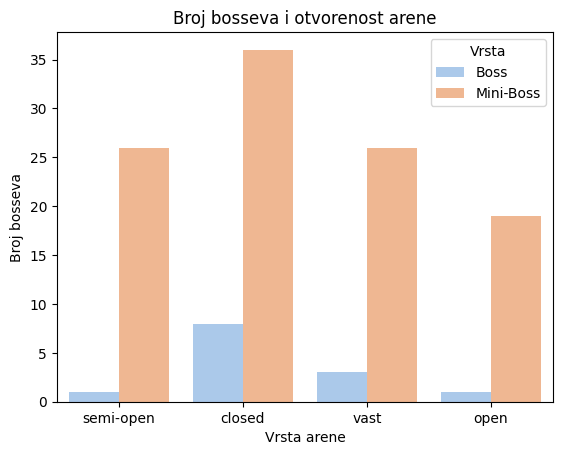

In [47]:
sns.countplot(data=df, x="arena_openness", hue = "type", palette = "pastel")
plt.title("Broj bosseva i otvorenost arene")
plt.xlabel("Vrsta arene")
plt.ylabel("Broj bosseva")
plt.legend(title = "Vrsta", loc = "upper right")
plt.show()


Seaborn graf **barplot** uzima neku kategoričku vrijednost za x os i neku numeričku vrijednost za y os te prikazuje *prosječnu vrijednost po kategoriji*
<br> Ja sam ga ovdje koristila da prikažem težinu bosseva ovisno o tome je li glavni ili mini boss

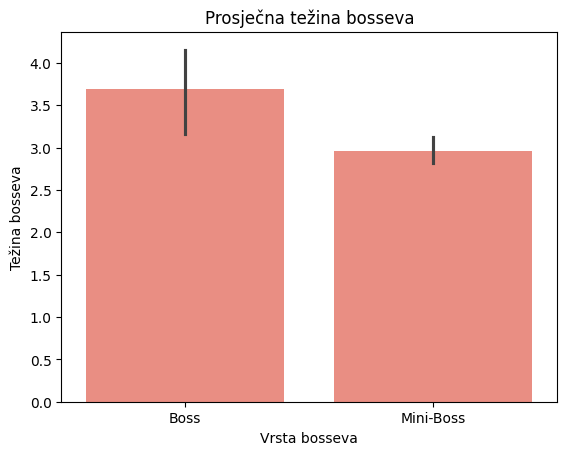

In [65]:
sns.barplot(data = df, x = "type", y = "lore_difficulty_rating", color = "salmon")
plt.xlabel("Vrsta bosseva")
plt.ylabel("Težina bosseva")
plt.title("Prosječna težina bosseva")
plt.show()

**Pie chart** grafički prikazuje podatke u obliku kruga ili "torte" gdje svaki segment prikazuje *udio određene kategorije u cjelini*
<br>Ja sam ga koristila da bi prikazala udio bosseva ovisno u kojem dijelu igre se nalazimo

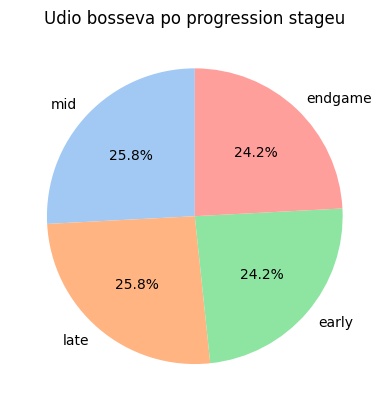

In [71]:
df["progression_stage"].value_counts().plot.pie(autopct = "%1.1f%%", startangle = 90, colors = sns.color_palette("pastel"))
plt.title("Udio bosseva po progression stageu")
plt.ylabel("")
plt.show()

**Histogram** koristimo za grafički prikaz numeričkih podataka i njim prikazujemo *učestalost podataka* (y os) u *određenim intervalima, tj. bins* (x os)
<br>Distribucija podataka može biti:
1. simetrična (podaci su ravnomjerno raspoređeni)
2. pozitivno skewed (podaci se "naginju" na lijevu stranu)
3. negativno skewed (podaci se "naginju" na desnu stranu)
<br> Ja sam ga koristila da bih prikazala distribuciju težine bosseva i u mom slučaju distribucija podataka je pozitivno skewed

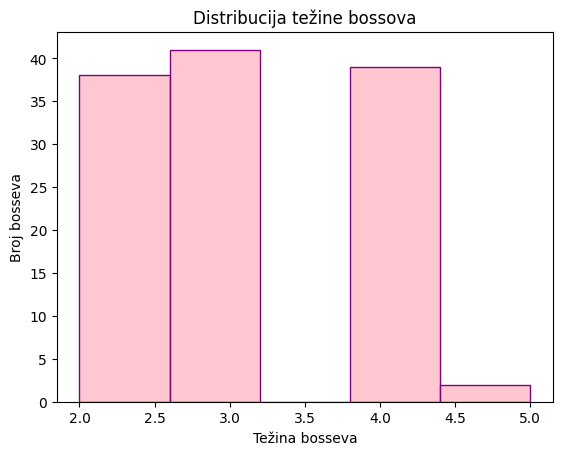

In [74]:
sns.histplot(data=df, x="lore_difficulty_rating", bins=5, color = "lightpink", edgecolor = "purple")
plt.title("Distribucija težine bosseva")
plt.xlabel("Težina bosseva")
plt.ylabel("Broj bosseva")
plt.show()
